# Dynamical Systems: bifurcations and chaos in population models

This notebook explores how simple nonlinear maps move from stable equilibria, through period-doubling, into chaos. It looks at the classic **logistic map** and a discrete **host–parasitoid** ecological model, combining numerical iteration, root-finding for fixed points, and bifurcation diagrams.

**Tools:** NumPy, SciPy (`fsolve`), Matplotlib.

## 1. Fixed points of the logistic map

For the map $f(x) = a\,x(1-x)$, the fixed points satisfy $f(x)=x$, i.e. the curve meets the diagonal $y=x$. Below, the intersections are found numerically with `fsolve` for three values of the parameter $a$.

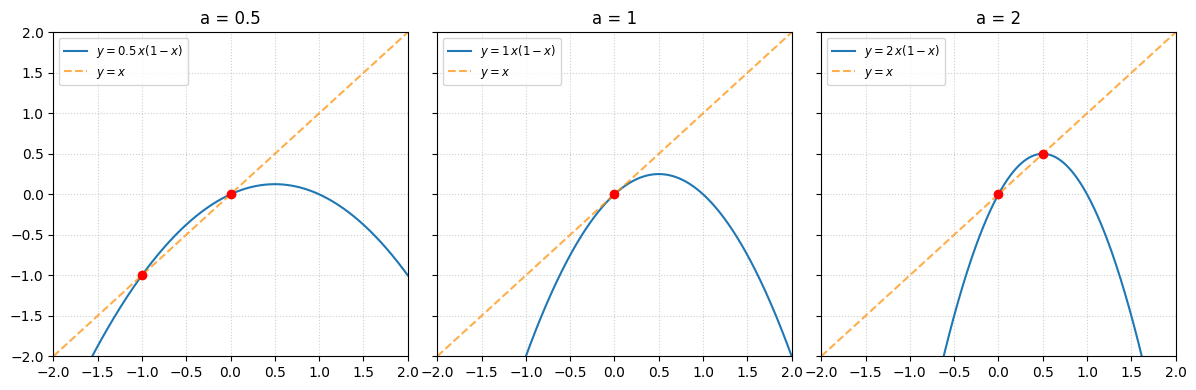

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import warnings
warnings.simplefilter('ignore', RuntimeWarning)

def f(a, x):
    return a * x * (1 - x)

params = [0.5, 1, 2]
x_range = np.linspace(-2, 2, 400)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, a in enumerate(params):
    axs[i].plot(x_range, f(a, x_range), label=f'$y={a}\\,x(1-x)$')
    axs[i].plot(x_range, x_range, '--', color='darkorange', alpha=0.7, label='$y=x$')
    roots = fsolve(lambda x: f(a, x) - x, [-1.0, 0.0, 1.0])
    for root in np.unique(np.round(roots, 6)):
        if -2 <= root <= 2:
            axs[i].plot(root, root, 'o', color='red', markersize=6)
    axs[i].set(xlim=(-2, 2), ylim=(-2, 2), title=f'a = {a}')
    axs[i].grid(True, linestyle=':', alpha=0.6)
    axs[i].legend(fontsize='small', loc='upper left')

plt.tight_layout()
plt.show()


## 2. Bifurcation diagram of the logistic map

Iterating $x_{n+1} = r\,x_n(1-x_n)$ and plotting the long-term values of $x$ against $r$ reveals the famous period-doubling route to chaos: a stable fixed point for $r<3$, splitting into 2-, 4-, 8-cycles, and chaotic bands beyond $r\approx 3.57$.

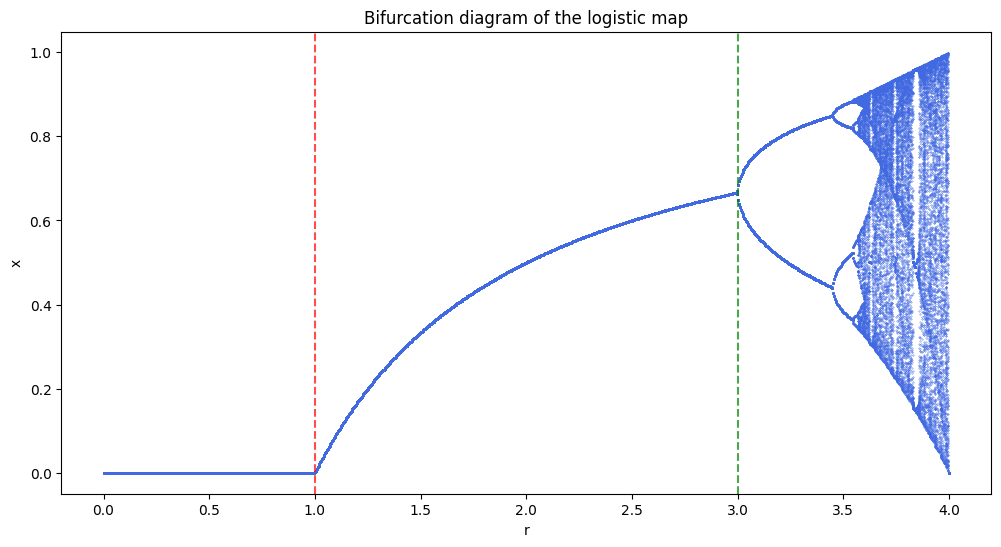

In [2]:
def logistic(r, x):
    return r * x * (1 - x)

r_values = np.linspace(0, 4, 1000)
rp, xp = [], []

for r in r_values:
    x = 0.5
    for _ in range(900):        # discard transient
        x = logistic(r, x)
    for _ in range(200):        # record attractor
        x = logistic(r, x)
        rp.append(r); xp.append(x)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(rp, xp, s=0.08, c='royalblue')
ax.set(xlabel='r', ylabel='x', title='Bifurcation diagram of the logistic map')
ax.axvline(1, c='red',   ls='--', alpha=0.7)
ax.axvline(3, c='green', ls='--', alpha=0.7)
plt.show()


## 3. Host–parasitoid model (Nicholson–Bailey type)

A discrete two-species model where a host population $H$ interacts with a parasitoid $P$:

$$H_{n+1} = H_n\,e^{\,r - H_n - aP_n}, \qquad P_{n+1} = H_n\bigl(1 - e^{-aP_n}\bigr).$$

Sweeping the host growth rate $r$ and recording the long-term host population produces the model's bifurcation diagram.

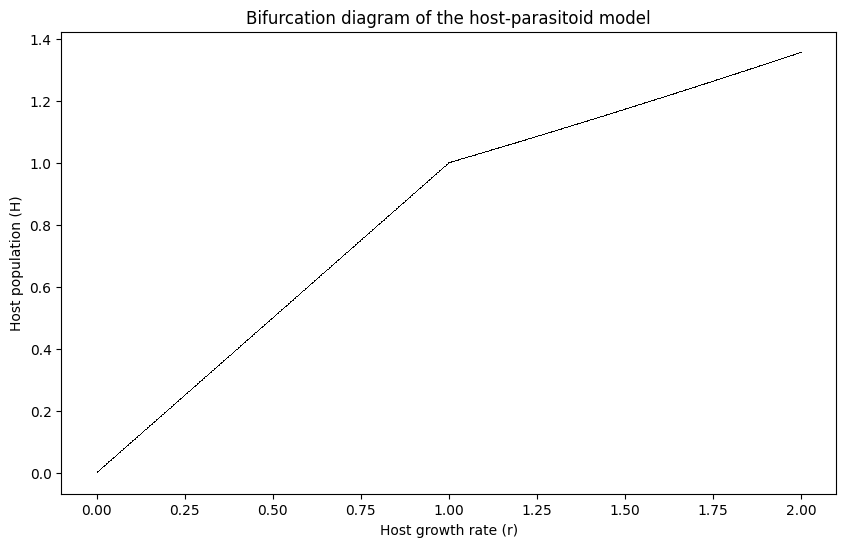

In [3]:
def nicholson_bailey(H, P, r, a):
    H_next = H * np.exp(r - H - a * P)
    P_next = H * (1 - np.exp(-a * P))
    return H_next, P_next

a = 1.0
r_values = np.linspace(0.0, 2.0, 1000)
iterations, last = 1000, 100
x_data, y_data = [], []

for r in r_values:
    H, P = 0.1, 0.1
    for i in range(iterations):
        H, P = nicholson_bailey(H, P, r, a)
        if i >= iterations - last:
            x_data.append(r); y_data.append(H)
        if H > 1e10 or H < 1e-10:
            break

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_data, y_data, ',k', alpha=0.3)
ax.set(xlabel='Host growth rate (r)', ylabel='Host population (H)',
       title='Bifurcation diagram of the host-parasitoid model')
plt.show()
